# **Notebook 1: Dual-View Chest X-ray Baseline**

**Description:** This notebook builds the foundation for the X-ray fusion project by converting IU chest X-ray image files and report metadata into a study-level classification dataset. It keeps studies with usable frontal and lateral images, derives the compact five-class target label, creates fixed train/validation/test splits, and trains the first text-only, image-only, and multimodal baselines.

**Main Questions This Notebook Should Answer:**
- Do image features, report text, or simple image/text fusion provide the strongest starting point?
- How much does the normal-class imbalance affect the first results?
- Should the project move toward stronger text encoders and more deliberate fusion designs?

---

# **Part 1: Configuration**
### **Imports**


In [1]:
from pathlib import Path
import sys
from collections import Counter
import re
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Ensure Python can find the local xray_fusion package.
PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents) if (candidate / "src" / "xray_fusion").exists()),
    Path.cwd(),
)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from xray_fusion.config import DEFAULT_IMAGE_SIZE, DEFAULT_MAX_LEN, find_project_root
from xray_fusion import data as xray_data
from xray_fusion import models as xray_models
from xray_fusion import training as xray_training
from xray_fusion import evaluation as xray_eval
from xray_fusion import segmentation as xray_segmentation
from xray_fusion import gradcam as xray_gradcam


Using device: cuda


### **Paths**


In [2]:
proj_path = PROJECT_ROOT / "indiana_projections.csv"
report_path = PROJECT_ROOT / "indiana_reports.csv"
image_dir = PROJECT_ROOT / "images_normalized"
split_dir = PROJECT_ROOT / "splits"
split_dir.mkdir(parents=True, exist_ok=True)


### **Configurations**


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 10
LR = 1e-4


### **Load raw tables**


In [4]:
proj_df = pd.read_csv(proj_path)
report_df = pd.read_csv(report_path)

print("Projection table shape:", proj_df.shape)
print("Report table shape:", report_df.shape)

display(proj_df.head())
display(report_df.head())


Projection table shape: (7466, 3)
Report table shape: (3851, 8)


,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal


,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


---
# **Part 2: Dataset Preparation**

### **Data Cleaning**


In [5]:
study_df = xray_data.build_study_level_table(proj_df, report_df, image_dir)

print("Study-level dataframe shape:", study_df.shape)
display(study_df[["uid", "frontal_path", "lateral_path", "indication", "impression"]].head())


Study-level dataframe shape: (3605, 14)


,uid,frontal_path,lateral_path,indication,impression
0,1,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,positive tb test,normal chest x-xxxx.
1,2,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,preop bariatric surgery.,no acute pulmonary findings.
2,3,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,"rib pain after a xxxx, xxxx xxxx steps this xx...","no displaced rib fractures, pneumothorax, or p..."
3,4,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,xxxx-year-old xxxx with xxxx.,1. bullous emphysema and interstitial fibrosis...
4,5,PROJECT_ROOT\ima...,PROJECT_ROOT\ima...,chest and nasal congestion.,no acute cardiopulmonary abnormality.


### **Inspect report-derived label candidates**


In [6]:
mesh_counter = Counter()
problem_counter = Counter()

for text in study_df["MeSH"]:
    mesh_counter.update(xray_data.split_semicolon_terms(text))

for text in study_df["Problems"]:
    problem_counter.update(xray_data.split_semicolon_terms(text))

mesh_counts_df = pd.DataFrame(mesh_counter.items(), columns=["label", "count"]).sort_values(
    "count", ascending=False
).reset_index(drop=True)

problem_counts_df = pd.DataFrame(problem_counter.items(), columns=["label", "count"]).sort_values(
    "count", ascending=False
).reset_index(drop=True)

print("Top MeSH labels")
display(mesh_counts_df.head(30))

print("Top Problem labels")
display(problem_counts_df.head(30))


Top MeSH labels


,label,count
0,normal,1313
1,lung/hypoinflation,228
2,lung/hyperdistention,160
3,cardiomegaly,129
4,cardiomegaly/mild,116
5,aorta/tortuous,107
6,technical quality of image unsatisfactory,99
7,spine/degenerative,98
8,thoracic vertebrae/degenerative,98
9,granulomatous disease,92


Top Problem labels


,label,count
0,normal,1313
1,lung,528
2,opacity,479
3,pulmonary atelectasis,313
4,cardiomegaly,309
5,calcinosis,303
6,calcified granuloma,252
7,thoracic vertebrae,228
8,cicatrix,181
9,spine,163


### **Create cleaner study-level labels**

The raw report space is too heterogeneous for a first baseline, so the label space is collapsed into five categories plus an other bucket.


In [7]:
study_df["clean_label"] = study_df.apply(xray_data.assign_clean_label, axis=1)

label_counts = study_df["clean_label"].value_counts().rename_axis("label").reset_index(name="count")
display(label_counts)


,label,count
0,normal,2302
1,other,461
2,pneumonia_or_opacity,309
3,cardiomegaly,254
4,pleural_effusion,171
5,chronic_lung_disease,108


### **Filter to the core classes and create train/validation/test splits**


In [8]:
keep_labels = [
    "normal",
    "cardiomegaly",
    "pleural_effusion",
    "pneumonia_or_opacity",
    "chronic_lung_disease",
]

model_df = study_df.loc[study_df["clean_label"].isin(keep_labels)].copy()

train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    stratify=model_df["clean_label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["clean_label"],
    random_state=SEED,
)

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name} shape:", df.shape)
    print(df["clean_label"].value_counts(normalize=True).round(3))
    print()

train_df.to_csv(split_dir / "train.csv", index=False)
val_df.to_csv(split_dir / "val.csv", index=False)
test_df.to_csv(split_dir / "test.csv", index=False)

print("Saved split CSVs to:", split_dir)


train shape: (2200, 15)
clean_label
normal                  0.732
pneumonia_or_opacity    0.098
cardiomegaly            0.081
pleural_effusion        0.055
chronic_lung_disease    0.034
Name: proportion, dtype: float64

val shape: (472, 15)
clean_label
normal                  0.733
pneumonia_or_opacity    0.100
cardiomegaly            0.081
pleural_effusion        0.053
chronic_lung_disease    0.034
Name: proportion, dtype: float64

test shape: (472, 15)
clean_label
normal                  0.731
pneumonia_or_opacity    0.097
cardiomegaly            0.081
pleural_effusion        0.055
chronic_lung_disease    0.036
Name: proportion, dtype: float64

Saved split CSVs to: PROJECT_ROOT\splits


### **Encode Labels**


In [9]:
label_encoder = LabelEncoder()
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["label_enc"] = label_encoder.fit_transform(train_df["clean_label"])
val_df["label_enc"] = label_encoder.transform(val_df["clean_label"])
test_df["label_enc"] = label_encoder.transform(test_df["clean_label"])

print("Label classes:", list(label_encoder.classes_))


Label classes: ['cardiomegaly', 'chronic_lung_disease', 'normal', 'pleural_effusion', 'pneumonia_or_opacity']


### **Image Transforms**


In [10]:
image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


### **Dataset Classes**


In [11]:
XRayDualImageDataset = xray_data.XRayDualImageDataset

class XRayMultimodalDataset(xray_data.XRayMultimodalDataset):
    def __init__(self, df, transform=None, max_len=40):
        encode_later = lambda text: encode_text(text, max_len=max_len)
        super().__init__(df, image_transform=transform, max_len=max_len, encode_fn=encode_later)


### **Build dataloaders**


In [12]:
train_ds = XRayDualImageDataset(train_df, transform=image_transform)
val_ds = XRayDualImageDataset(val_df, transform=image_transform)
test_ds = XRayDualImageDataset(test_df, transform=image_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

frontal_batch, lateral_batch, label_batch = next(iter(train_loader))
print("Frontal batch shape:", tuple(frontal_batch.shape))
print("Lateral batch shape:", tuple(lateral_batch.shape))
print("Label batch shape:", tuple(label_batch.shape))


Frontal batch shape: (32, 3, 224, 224)
Lateral batch shape: (32, 3, 224, 224)
Label batch shape: (32,)


### **Class Weights**


In [13]:
class_counts = train_df["clean_label"].value_counts()
class_weights = torch.tensor(
    [len(train_df) / class_counts[label] for label in label_encoder.classes_],
    dtype=torch.float32,
    device=device,
)
class_weights

tensor([12.3596, 29.3333,  1.3656, 18.3333, 10.1852], device='cuda:0')

---

# **Part 3: Baselines**

### **Text-Only Baseline**


In [14]:
X_train_text = train_df["indication"].fillna("")
X_val_text = val_df["indication"].fillna("")
X_test_text = test_df["indication"].fillna("")

y_train = train_df["clean_label"]
y_val = val_df["clean_label"]
y_test = test_df["clean_label"]

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_features=5000,
)

X_train_vec = vectorizer.fit_transform(X_train_text)
X_val_vec = vectorizer.transform(X_val_text)
X_test_vec = vectorizer.transform(X_test_text)

text_clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=SEED,
)

text_clf.fit(X_train_vec, y_train)

val_pred = text_clf.predict(X_val_vec)
test_pred = text_clf.predict(X_test_vec)

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print()
print(classification_report(y_test, test_pred, digits=4))


Validation Accuracy: 0.3728813559322034
Test Accuracy: 0.3961864406779661

                      precision    recall  f1-score   support

        cardiomegaly     0.1379    0.3158    0.1920        38
chronic_lung_disease     0.0897    0.4118    0.1474        17
              normal     0.8095    0.4435    0.5730       345
    pleural_effusion     0.0833    0.1538    0.1081        26
pneumonia_or_opacity     0.1571    0.2391    0.1897        46

            accuracy                         0.3962       472
           macro avg     0.2555    0.3128    0.2420       472
        weighted avg     0.6259    0.3962    0.4641       472



### **Text-Only Baseline Results Interpretation**

The text-only baseline performed poorly overall, reaching 0.396 test accuracy and 0.242 macro F1. Its balanced class weighting helped it predict some abnormal labels, but precision was low across the disease classes and normal recall dropped to 0.444. This suggests that the indication text alone is too noisy and incomplete to serve as the main diagnostic signal for this dataset.


### **Dual-View Image Baseline Class**


In [15]:
DualImageModel = xray_models.DualImageClassifier
model = DualImageModel(num_classes=len(label_encoder.classes_)).to(device)


### **Training Functions**


In [16]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

train_epoch = lambda model, loader: xray_training.train_dual_image_epoch(
    model, loader, criterion, optimizer, device, desc="Train"
)
evaluate = lambda model, loader: xray_training.evaluate_dual_image(
    model, loader, criterion, device, desc="Eval"
)


### **Train Model**


In [17]:
history = []

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )
    print()


Epoch 1/10


Train:   0%|          | 0/69 [00:00<?, ?it/s]

Eval:   0%|          | 0/15 [00:00<?, ?it/s]

train_loss=1.4376 | train_acc=0.5127 | val_loss=1.2830 | val_acc=0.7097

Epoch 2/10


Train:   0%|          | 0/69 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/15 [00:00<?, ?it/s]

train_loss=0.0049 | train_acc=1.0000 | val_loss=3.7576 | val_acc=0.7712

Epoch 10/10


Train:   0%|          | 0/69 [00:00<?, ?it/s]

Eval:   0%|          | 0/15 [00:00<?, ?it/s]

train_loss=0.0025 | train_acc=1.0000 | val_loss=3.8823 | val_acc=0.7733



### **Plot training history**


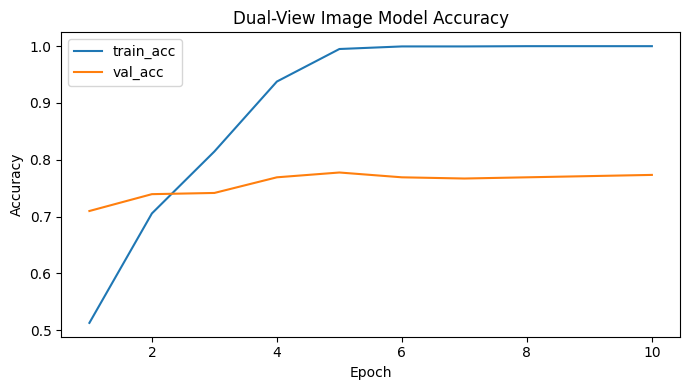

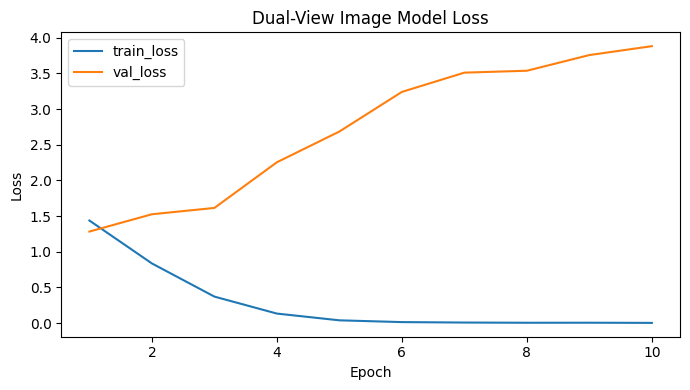

In [18]:
history_df = pd.DataFrame(history)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df["epoch"], history_df["train_acc"], label="train_acc")
ax.plot(history_df["epoch"], history_df["val_acc"], label="val_acc")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Dual-View Image Model Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
ax.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Dual-View Image Model Loss")
ax.legend()
plt.tight_layout()
plt.show()


### **Confusion Matrix**


Eval:   0%|          | 0/15 [00:00<?, ?it/s]

Test Loss: 4.5463
Test Accuracy: 0.75

                      precision    recall  f1-score   support

        cardiomegaly     0.6667    0.0526    0.0976        38
chronic_lung_disease     1.0000    0.1176    0.2105        17
              normal     0.7572    0.9942    0.8596       345
    pleural_effusion     0.5000    0.1154    0.1875        26
pneumonia_or_opacity     0.5000    0.0870    0.1481        46

            accuracy                         0.7500       472
           macro avg     0.6848    0.2734    0.3007       472
        weighted avg     0.7194    0.7500    0.6685       472



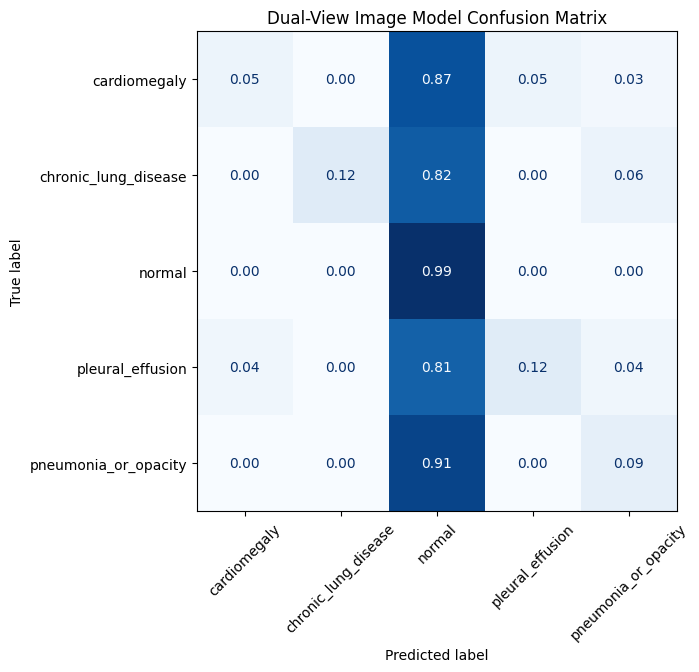

In [19]:
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))
print()
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, digits=4))

cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False)
ax.set_title("Dual-View Image Model Confusion Matrix")
plt.tight_layout()
plt.show()


### **Dual-View Image Baseline Results Interpretation**

The dual-view image baseline was a much stronger starting point, reaching 0.750 test accuracy compared with 0.396 for text-only. The model learned the normal class well, with 0.994 recall, but it missed most abnormal studies, with disease-class recalls between 0.053 and 0.118. Therefore, the high accuracy is likely mainly driven by the normal-heavy test set instead of balanced disease recognition.


---

# **Part 4: Multimodal Fusion Model**


### **Text Vocabulary + Encoding**


In [20]:
MAX_VOCAB = 5000
MAX_LEN = 40
vocab = xray_data.build_vocabulary(train_df["indication"].fillna(""), max_vocab=MAX_VOCAB)

def tokenize(text):
    return str(text).lower().split()

def encode_text(text, max_len=MAX_LEN):
    return xray_data.encode_text(text, vocab, max_len)

train_mm_ds = XRayMultimodalDataset(train_df, transform=image_transform, max_len=MAX_LEN)
val_mm_ds = XRayMultimodalDataset(val_df, transform=image_transform, max_len=MAX_LEN)
test_mm_ds = XRayMultimodalDataset(test_df, transform=image_transform, max_len=MAX_LEN)

train_mm_loader = DataLoader(train_mm_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_mm_loader = DataLoader(val_mm_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_mm_loader = DataLoader(test_mm_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

frontal_batch, lateral_batch, text_batch, label_batch = next(iter(train_mm_loader))
print("Fusion frontal batch shape:", tuple(frontal_batch.shape))
print("Fusion lateral batch shape:", tuple(lateral_batch.shape))
print("Fusion text batch shape:", tuple(text_batch.shape))
print("Fusion label batch shape:", tuple(label_batch.shape))


Fusion frontal batch shape: (32, 3, 224, 224)
Fusion lateral batch shape: (32, 3, 224, 224)
Fusion text batch shape: (32, 40)
Fusion label batch shape: (32,)


### **Model Class**


In [21]:
MultimodalFusionModel = xray_models.SimpleVocabularyFusionClassifier

fusion_model = MultimodalFusionModel(
    num_classes=len(label_encoder.classes_),
    vocab_size=len(vocab),
).to(device)

fusion_optimizer = torch.optim.Adam(fusion_model.parameters(), lr=LR)
fusion_criterion = nn.CrossEntropyLoss(weight=class_weights)


### **Training Functions**


In [22]:
train_epoch_fusion = lambda model, loader: xray_training.train_simple_fusion_epoch(
    model, loader, fusion_criterion, fusion_optimizer, device, desc="Train Fusion"
)
evaluate_fusion = lambda model, loader: xray_training.evaluate_simple_fusion(
    model, loader, fusion_criterion, device, desc="Eval Fusion"
)


### **Train Model**


In [24]:
fusion_history = []

for epoch in range(1, EPOCHS + 1):
    print(f"Epoch {epoch}/{EPOCHS}")

    train_loss, train_acc = train_epoch_fusion(fusion_model, train_mm_loader)
    val_loss, val_acc, _, _ = evaluate_fusion(fusion_model, val_mm_loader)

    fusion_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )
    print()

Epoch 1/10


Train Fusion:   0%|          | 0/69 [00:00<?, ?it/s]

Eval Fusion:   0%|          | 0/15 [00:00<?, ?it/s]

train_loss=1.4608 | train_acc=0.4045 | val_loss=1.3480 | val_acc=0.7161

Epoch 2/10


Train Fusion:   0%|          | 0/69 [00:00<?, ?it/s]

...

Eval Fusion:   0%|          | 0/15 [00:00<?, ?it/s]

train_loss=0.0099 | train_acc=0.9991 | val_loss=4.0773 | val_acc=0.7669

Epoch 10/10


Train Fusion:   0%|          | 0/69 [00:00<?, ?it/s]

Eval Fusion:   0%|          | 0/15 [00:00<?, ?it/s]

train_loss=0.0052 | train_acc=0.9991 | val_loss=3.8688 | val_acc=0.7712



### **Confusion Matrix**


Eval Fusion:   0%|          | 0/15 [00:00<?, ?it/s]

Fusion Test Loss: 4.1618
Fusion Test Accuracy: 0.7691

                      precision    recall  f1-score   support

        cardiomegaly     0.8333    0.1316    0.2273        38
chronic_lung_disease     0.7500    0.1765    0.2857        17
              normal     0.7667    1.0000    0.8679       345
    pleural_effusion     0.7500    0.1154    0.2000        26
pneumonia_or_opacity     0.8750    0.1522    0.2593        46

            accuracy                         0.7691       472
           macro avg     0.7950    0.3151    0.3680       472
        weighted avg     0.7811    0.7691    0.6993       472



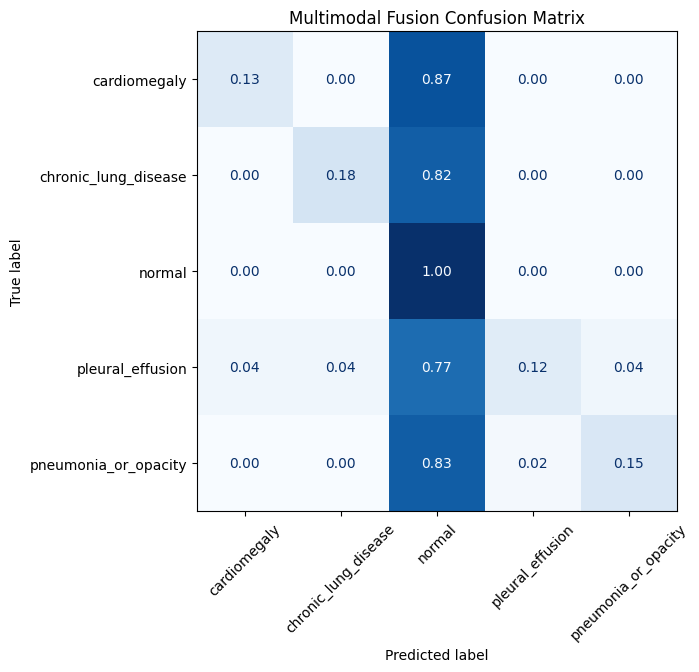

In [26]:
fusion_test_loss, fusion_test_acc, y_true, y_pred = evaluate_fusion(fusion_model, test_mm_loader)

print("Fusion Test Loss:", round(fusion_test_loss, 4))
print("Fusion Test Accuracy:", round(fusion_test_acc, 4))
print()
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, digits=4))

cm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format=".2f", colorbar=False)
ax.set_title("Multimodal Fusion Confusion Matrix")
plt.tight_layout()
plt.show()

### **Multimodal Fusion Model Results Interpretation**

The first multimodal fusion model produced the best overall accuracy at 0.769 and improved macro F1 to 0.368. It also raised abnormal-class recall compared with the dual-view image baseline for cardiomegaly, chronic lung disease, pleural effusion, and pneumonia/opacity. Even so, normal recall reached 1.000 while abnormal recall remained low, so this simple fusion setup still does not solve the class-imbalance problem.



### **Final Model Comparison**


In [27]:
comparison_df = pd.DataFrame([
    {"model": "text_only", "test_acc": accuracy_score(y_test, test_pred)},
    {"model": "dual_view_image", "test_acc": test_acc},
    {"model": "fusion", "test_acc": fusion_test_acc},
]).sort_values("test_acc", ascending=False)

display(comparison_df)

,model,test_acc
2,fusion,0.769068
1,dual_view_image,0.750000
0,text_only,0.396186


### **Final Model Comparison Interpretation**

The final comparison shows that the text-only model performs the worst, with an accuracy of 0.396, while the dual-view image model performs better at 0.750. The simple image-text fusion model achieves the highest accuracy at 0.769. These results demonstrate that image data provides a much stronger basis for prediction than using text data alone. Combining image and text information also improves results, although the gain over the image-only model is somewhat small. This suggests that multimodal medical imaging systems have the potential to outperform models that rely exclusively on either images or text. Later experiments will retain the fusion model and investigate whether additional improvements can be achieved through more advanced multimodal approaches.



---

# **Part 5: Conclusion**

This notebook established the core dataset and baseline modeling problem for the project. It converted the IU chest X-ray image/report metadata into a five-class study-level classification task, retained studies with both frontal and lateral images, and created fixed train, validation, and test splits that will be reused throughout later notebooks. This provides a consistent foundation for comparing future experiments using the same label space, paired-image requirement, and data splits.

The baseline results show that image information provides the strongest starting point. The text-only model reached 0.396 test accuracy, while the dual-view image model improved substantially to 0.750, showing that the frontal and lateral X-ray views contain much stronger predictive signal than the initial text representation. The first multimodal fusion model performed best overall, reaching 0.769 test accuracy and a macro F1 of 0.368. This supports the main direction of the project, showing that combining image and text information can improve performance beyond either modality alone. However, the improvement over image-only classification is relatively small, and performance remains heavily influenced by the normal class, with much weaker recall across the abnormal categories.

These results support continuing with multimodal learning while also showing the class-imbalance and minority-class recall problems that later notebooks need to address. More broadly, the results suggest that when both imaging and relevant text data are available, combining the two may provide more useful context. For example, in a clinical system, information from someones medical record could be incorporated with appropriate consent and privacy protections, allowing prior clinical context to complement the image data instead of relying only on the image.

---
